# 👨 Day 23 - Customer Loyalty & CLV Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("sales_data_sample.csv", encoding='latin1')

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [2]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [3]:
"Rows:", len(df)

('Rows:', 2823)

In [4]:
# Keep needed columns
df = df[['CUSTOMERNAME','ORDERDATE','SALES','STATUS']]

# Convert date to datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Drop null
df = df.dropna()

df.head()

,CUSTOMERNAME,ORDERDATE,SALES,STATUS
0,Land of Toys Inc.,2003-02-24,2871.00,Shipped
1,Reims Collectables,2003-05-07,2765.90,Shipped
2,Lyon Souveniers,2003-07-01,3884.34,Shipped
3,Toys4GrownUps.com,2003-08-25,3746.70,Shipped
4,Corporate Gift Ideas Co.,2003-10-10,5205.27,Shipped


In [5]:
# cell 2
# Inspect typical columns and rename to standard names if required.
# We expect columns like: 'Customer', 'OrderDate', 'OrderID', 'Sales' (or 'Amount', 'Revenue')

# Print sample column names and some values to identify which columns to use
print(df.columns)
print(df.dtypes)
print(df.head(3))

# Map typical column names to standard names used by this pipeline.
# EDIT these lines if your CSV has different column names.
col_customer = None
col_date = None
col_amount = None
possible_customer = ['CUSTOMERNAME','Customer','CustomerID','customer','customer_id','cust_name']
possible_date = ['ORDERDATE','order_date','OrderDate','DATE','Date','orderdate']
possible_amount = ['SALES','Sales','sales','Amount','AMOUNT','Revenue','revenue','Total']

for c in df.columns:
    if c in possible_customer:
        col_customer = c
    if c in possible_date:
        col_date = c
    if c in possible_amount:
        col_amount = c

# If automatic mapping failed, try heuristics
if col_customer is None:
    # try columns with 'cust' substring
    for c in df.columns:
        if 'cust' in c.lower() or 'customer' in c.lower():
            col_customer = c
            break

if col_date is None:
    for c in df.columns:
        if 'date' in c.lower() or 'order' in c.lower():
            col_date = c
            break

if col_amount is None:
    for c in df.columns:
        if 'sale' in c.lower() or 'amount' in c.lower() or 'revenue' in c.lower() or 'total' in c.lower():
            col_amount = c
            break

print("Detected columns -> customer:", col_customer, " date:", col_date, " amount:", col_amount)

# If any not found, raise with helpful message
if col_customer is None or col_date is None or col_amount is None:
    raise ValueError("Couldn't automatically detect customer/date/amount columns. Edit col_customer/col_date/col_amount variables to your CSV column names.")

# Keep only needed columns and rename
df = df[[col_customer, col_date, col_amount]].rename(columns={
    col_customer: "CustomerID",
    col_date: "OrderDate",
    col_amount: "Amount"
})

# Parse dates
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
# Drop rows with invalid date or null amount/customer
df = df.dropna(subset=['OrderDate', 'CustomerID', 'Amount'])
# Ensure numeric amount
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df = df.dropna(subset=['Amount'])

print("After cleaning rows:", len(df))
df.sample(3)


Index(['CUSTOMERNAME', 'ORDERDATE', 'SALES', 'STATUS'], dtype='object')
CUSTOMERNAME            object
ORDERDATE       datetime64[ns]
SALES                  float64
STATUS                  object
dtype: object
         CUSTOMERNAME  ORDERDATE    SALES   STATUS
0   Land of Toys Inc. 2003-02-24  2871.00  Shipped
1  Reims Collectables 2003-05-07  2765.90  Shipped
2     Lyon Souveniers 2003-07-01  3884.34  Shipped
Detected columns -> customer: CUSTOMERNAME  date: ORDERDATE  amount: SALES
After cleaning rows: 2823


,CustomerID,OrderDate,Amount
194,Super Scale Inc.,2003-11-26,8887.7
692,Amica Models & Co.,2004-08-17,1574.0
1452,Mini Gifts Distributors Ltd.,2004-07-20,2913.3


In [6]:
# cell 3 - RFM and aggregated features
# Use last date in dataset as reference 'today' (common approach)
snapshot_date = df['OrderDate'].max() + pd.Timedelta(days=1)
print("Snapshot date (reference):", snapshot_date.date())

# Aggregate per customer
agg = df.groupby('CustomerID').agg(
    Recency=('OrderDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('OrderDate', lambda x: x.nunique()),     # unique order days or order count; choose as you like
    Monetary=('Amount', 'sum'),
    AvgOrderValue=('Amount', 'mean'),
    OrderCount=('Amount', 'count'),
    FirstPurchase=('OrderDate', 'min'),
    LastPurchase=('OrderDate', 'max')
).reset_index()

# Additional features
agg['CustomerAgeDays'] = (agg['LastPurchase'] - agg['FirstPurchase']).dt.days.fillna(0).astype(int)
# For convenience, create log features to stabilize distribution
agg['LogMonetary'] = np.log1p(agg['Monetary'])
agg['LogAvgOrderValue'] = np.log1p(agg['AvgOrderValue'])
agg['LogFrequency'] = np.log1p(agg['Frequency'])

# Define CLV target (simple proxy = Monetary total)
# If you have future period data, you'd compute future sales; here we use historical total as proxy.
agg['CLV'] = agg['Monetary']

agg.head()

Snapshot date (reference): 2005-06-01


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,OrderCount,FirstPurchase,LastPurchase,CustomerAgeDays,LogMonetary,LogAvgOrderValue,LogFrequency,CLV
0,"AV Stores, Co.",196,3,157807.81,3094.270784,51,2003-03-18,2004-11-17,610,11.969140,8.037631,1.386294,157807.81
1,Alpha Cognac,65,3,70488.44,3524.422000,20,2003-07-04,2005-03-28,633,11.163218,8.167755,1.386294,70488.44
2,Amica Models & Co.,265,2,94117.26,3619.894615,26,2004-08-17,2004-09-09,23,11.452307,8.194476,1.098612,94117.26
3,"Anna's Decorations, Ltd",84,4,153996.13,3347.741957,46,2003-09-11,2005-03-09,545,11.944689,8.116340,1.609438,153996.13
4,Atelier graphique,188,3,24179.96,3454.280000,7,2003-05-20,2004-11-25,555,10.093321,8.147659,1.386294,24179.96


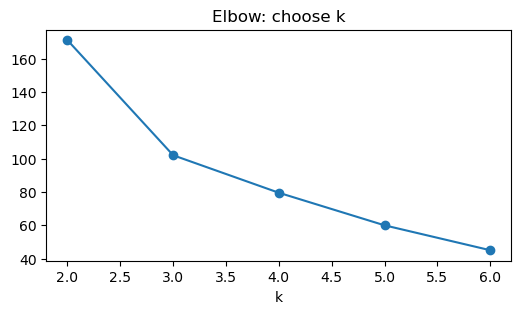

Cluster
1    43
2    35
0    12
3     2
Name: count, dtype: int64
         Recency  Frequency    Monetary
Cluster                                
0          458.5        2.0   58911.790
1           84.0        3.0  118008.270
2          210.0        2.0   75238.920
3            2.0       21.0  783576.085


In [7]:
# cell 4 - RFM segmentation and KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare RFM matrix for clustering (use Recency, Frequency, Monetary)
rfm = agg[['CustomerID','Recency','Frequency','Monetary']].copy()
X_rfm = rfm[['Recency','Frequency','Monetary']].fillna(0).values

# log transform Monetary and Frequency (optional) for better clustering
X_rfm[:,2] = np.log1p(X_rfm[:,2])
X_rfm[:,1] = np.log1p(X_rfm[:,1])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

# Determine cluster count using elbow (optional) — we'll choose k=4 by default
inertia = []
K=range(2,7)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,3))
plt.plot(K, inertia, '-o')
plt.xlabel('k')
plt.title('Elbow: choose k')
plt.show()

# Fit KMeans with k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Map cluster sizes
print(rfm['Cluster'].value_counts())

# Merge cluster back to agg
agg = agg.merge(rfm[['CustomerID','Cluster']], on='CustomerID', how='left')

# Inspect cluster means
print(agg.groupby('Cluster')[['Recency','Frequency','Monetary']].median())

In [8]:
# cell 5 - loyalty score
# Simple weighted score (you can tune weights)
# Higher Frequency & Monetary increase score; lower Recency increases score.
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0,100))
# Use features Frequency (higher better), Monetary (higher better), Recency (lower better -> invert)
agg['Recency_inv'] = agg['Recency'].max() - agg['Recency']

score_matrix = agg[['Recency_inv','Frequency','Monetary']].fillna(0).values
agg['LoyaltyScore'] = sc.fit_transform(score_matrix).mean(axis=1)  # naive average across scaled features

# create VIP label: top 10% CLV as VIP
vip_thresh = agg['CLV'].quantile(0.9)
agg['VIP'] = (agg['CLV'] >= vip_thresh).astype(int)

agg[['CustomerID','Recency','Frequency','Monetary','LoyaltyScore','CLV','VIP']].head()

,CustomerID,Recency,Frequency,Monetary,LoyaltyScore,CLV,VIP
0,"AV Stores, Co.",196,3,157807.81,28.803150,157807.81,1
1,Alpha Cognac,65,3,70488.44,34.176232,70488.44,0
2,Amica Models & Co.,265,2,94117.26,20.536058,94117.26,0
3,"Anna's Decorations, Ltd",84,4,153996.13,37.400441,153996.13,1
4,Atelier graphique,188,3,24179.96,24.396247,24179.96,0


In [9]:
# cell 6 - training XGBoost for CLV
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features list
features = ['Recency','Frequency','AvgOrderValue','OrderCount','CustomerAgeDays','LogMonetary','LogAvgOrderValue','LogFrequency','Cluster','LoyaltyScore']

# Fill NaNs
agg[features] = agg[features].fillna(0)

# Train-test split
X = agg[features]
y = agg['CLV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost regressor
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predictions & evaluation
preds = xgb.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

RMSE: 198226.7308190244
MAE: 65838.65983963816
R2: -1.2308960565121119


In [10]:
# cell 7 - VIP classifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

clf = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, (y_train >= vip_thresh).astype(int))

yhat = clf.predict(X_test)
print(classification_report((y_test >= vip_thresh).astype(int), yhat))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         3

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



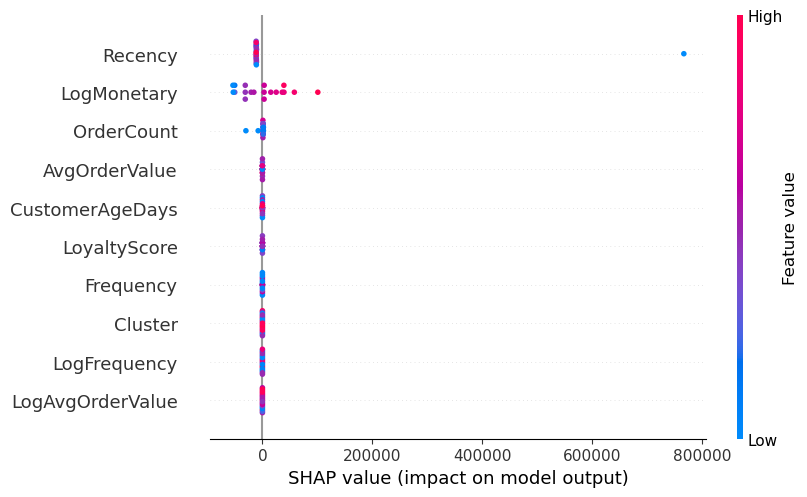

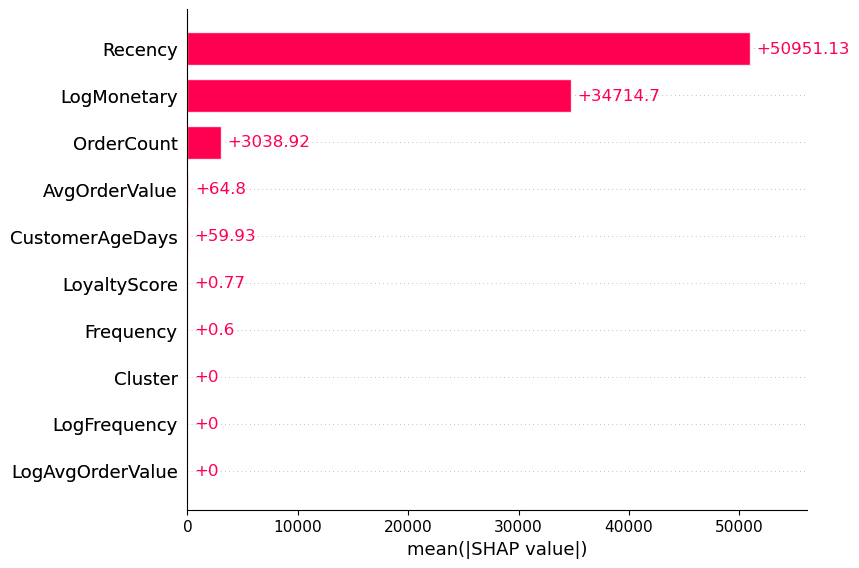

In [11]:
# cell 8 - SHAP
import shap
shap.initjs()

# Use TreeExplainer for XGBoost
explainer = shap.Explainer(xgb)
# Compute shap values on a sample (to save time)
sample_X = X_test.sample(min(200, len(X_test)), random_state=42)
shap_values = explainer(sample_X)

# Summary plot (global importance)
shap.plots.beeswarm(shap_values, max_display=10)

# Feature importance (bar)
shap.plots.bar(shap_values, max_display=10)

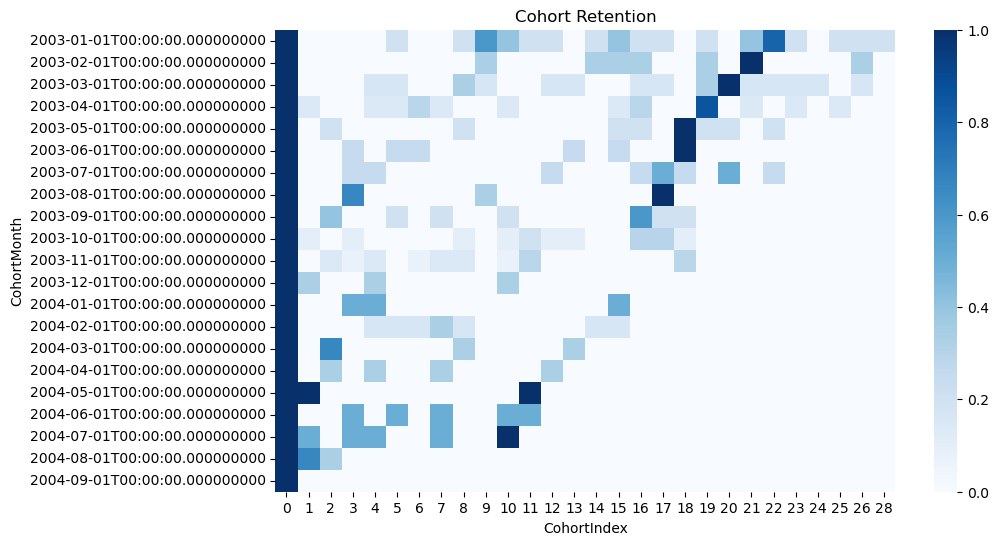

In [12]:
# cell 9 - cohort analysis
df['OrderMonth'] = df['OrderDate'].dt.to_period('M').dt.to_timestamp()
# assign cohort = first order month per customer
first_order = df.groupby('CustomerID')['OrderMonth'].min().reset_index().rename(columns={'OrderMonth':'CohortMonth'})
df = df.merge(first_order, on='CustomerID', how='left')

# compute months between cohort and order
def month_diff(dt1, dt2):
    return (dt1.dt.year - dt2.dt.year) * 12 + (dt1.dt.month - dt2.dt.month)

df['CohortIndex'] = month_diff(df['OrderMonth'], df['CohortMonth'])

cohort_data = df.groupby(['CohortMonth','CohortIndex']).agg({'CustomerID': pd.Series.nunique}).reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_sizes = cohort_counts.iloc[:,0]

# retention matrix as percentages
retention = cohort_counts.divide(cohort_sizes, axis=0)
plt.figure(figsize=(10,6))
plt.title('Cohort Retention')
sns.heatmap(retention.fillna(0), annot=False, fmt='.0%', cmap='Blues')
plt.show()

In [13]:
# cell 10 - save model, agg to CSV for Streamlit
import joblib
joblib.dump(xgb, "xgb_model.joblib")
agg.to_csv("agg_customers.csv", index=False)
print("Saved xgb_model.joblib and agg_customers.csv")

Saved xgb_model.joblib and agg_customers.csv
